# Suspicious Transaction Detection — DSC Hackathon 2026
### Data Science Club | Sol Plaatje University

## Our Scenario
We are the **fraud analytics team** at a South African mobile money provider. Following South
Africa's 2023 FATF greylisting, our compliance department has asked us to strengthen transaction
monitoring. We have been handed a sample of **~630,000 mobile money transactions** (a stratified
10% sample of a 6.3 million-row log) and asked to:

1. **Explore** the data and understand what separates fraudulent transactions from legitimate ones.
2. **Detect** fraud using a model built on the patterns we find.
3. **Recommend** what the bank should do which transaction types to watch, and how to weigh
   missed fraud against false alarms.

This notebook covers **Part 1 — Exploratory Data Analysis (EDA)**. Every chart and table here is
chosen because it answers a question a bank's fraud team would actually ask, not just because it
looks interesting. A short baseline model is included at the end as a starting point for Part 2.


## 1. Setup

In [1]:
# Core libraries for data handling, numerical work, and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Load and Inspect the Data

In [2]:
# Load the transaction dataset
df = pd.read_csv("Datasets_For_Fraud_Detection.csv")

print("Shape:", df.shape)
df.head()


Shape: (636262, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,182,CASH_IN,100328.70,C197678862,3389602.37,3489931.07,C386191921,219735.14,119406.44,0,0
1,210,PAYMENT,11660.99,C2009511954,94054.00,82393.01,M564284134,0.00,0.00,0,0
2,403,CASH_IN,230751.30,C1132312861,23117012.10,23347763.39,C1025694734,951294.81,720543.51,0,0
3,328,PAYMENT,17833.60,C1191709365,0.00,0.00,M293024801,0.00,0.00,0,0
4,563,CASH_OUT,246476.67,C342438889,0.00,0.00,C2087488957,4226850.16,4473326.82,0,0


In [3]:
# Data types and non-null counts - confirms we know what we're working with
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636262 entries, 0 to 636261
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            636262 non-null  int64  
 1   type            636262 non-null  object 
 2   amount          636262 non-null  float64
 3   nameOrig        636262 non-null  object 
 4   oldbalanceOrg   636262 non-null  float64
 5   newbalanceOrig  636262 non-null  float64
 6   nameDest        636262 non-null  object 
 7   oldbalanceDest  636262 non-null  float64
 8   newbalanceDest  636262 non-null  float64
 9   isFraud         636262 non-null  int64  
 10  isFlaggedFraud  636262 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 53.4+ MB


In [4]:
# Any missing values or duplicate rows to clean up first?
print("Missing values per column:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Missing values per column:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Duplicate rows: 0


**Note on columns:**
- `step` = one simulation hour (1–743 hours ≈ 31 days)
- `type` = transaction type (CASH_IN, CASH_OUT, DEBIT, PAYMENT, TRANSFER)
- `amount`, `oldbalanceOrg`/`newbalanceOrig` = sender's balance before/after
- `oldbalanceDest`/`newbalanceDest` = recipient's balance before/after
- `isFraud` = ground truth label (1 = fraudulent transaction)
- `isFlaggedFraud` = the bank's *existing* rule-based system's flag (1 = flagged)

No missing values and no duplicates, so we can move straight to exploring the fraud pattern.


## 3. How Rare is Fraud? (Class Imbalance)

isFraud
0    635413
1       849
Name: count, dtype: int64

Fraud rate: 0.133% of all transactions


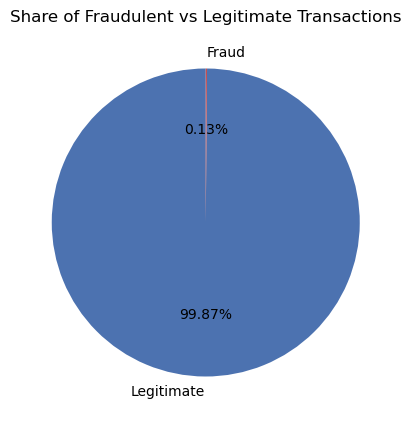

In [5]:
fraud_counts = df["isFraud"].value_counts()
fraud_rate = df["isFraud"].mean() * 100

print(fraud_counts)
print(f"\nFraud rate: {fraud_rate:.3f}% of all transactions")

# Visualise the imbalance - this is the single most important fact for Part 2 (modelling)
plt.figure(figsize=(5, 5))
plt.pie(fraud_counts, labels=["Legitimate", "Fraud"], autopct="%1.2f%%",
        colors=["#4C72B0", "#C44E52"], startangle=90)
plt.title("Share of Fraudulent vs Legitimate Transactions")
plt.show()


**Insight:** Fraud makes up roughly **0.13%** of transactions. This extreme imbalance is why
"accuracy" is a misleading metric for Part 2 - a model that predicts "not fraud" every single time
would already be 99.87% "accurate" while catching zero fraud. We'll need precision/recall-based
metrics and a cost-based threshold instead.


## 4. Which Transaction Types Carry the Fraud Risk?

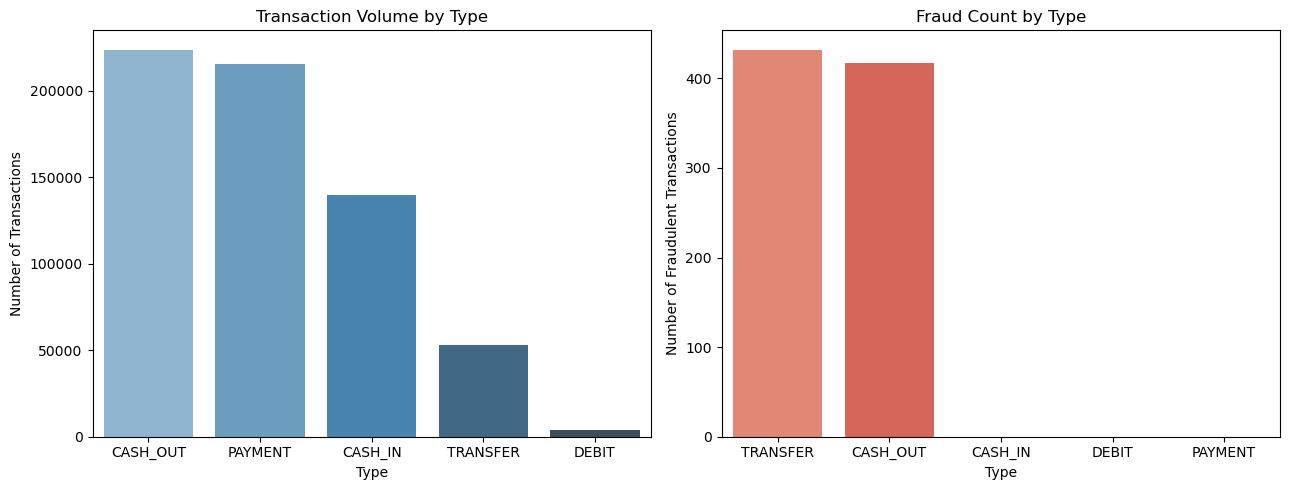

type
TRANSFER    432
CASH_OUT    417
CASH_IN       0
DEBIT         0
PAYMENT       0
Name: isFraud, dtype: int64


In [6]:
# Count of each transaction type, and how many frauds fall in each
type_counts = df["type"].value_counts()
fraud_by_type = df.groupby("type")["isFraud"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(x=type_counts.index, y=type_counts.values, ax=axes[0], hue=type_counts.index,
            palette="Blues_d", legend=False)
axes[0].set_title("Transaction Volume by Type")
axes[0].set_ylabel("Number of Transactions")
axes[0].set_xlabel("Type")

sns.barplot(x=fraud_by_type.index, y=fraud_by_type.values, ax=axes[1], hue=fraud_by_type.index,
            palette="Reds_d", legend=False)
axes[1].set_title("Fraud Count by Type")
axes[1].set_ylabel("Number of Fraudulent Transactions")
axes[1].set_xlabel("Type")

plt.tight_layout()
plt.show()

print(fraud_by_type)


**Insight:** Every single fraudulent transaction in this data is a **TRANSFER** or a
**CASH_OUT**. PAYMENT, CASH_IN, and DEBIT transactions carry zero fraud despite high volume. This
immediately narrows where a bank should focus monitoring effort - and it means a model could
restrict its search space to these two transaction types, which reduces false-alarm volume in the
other three.


## 5. Transaction Amounts: Fraud vs Legitimate

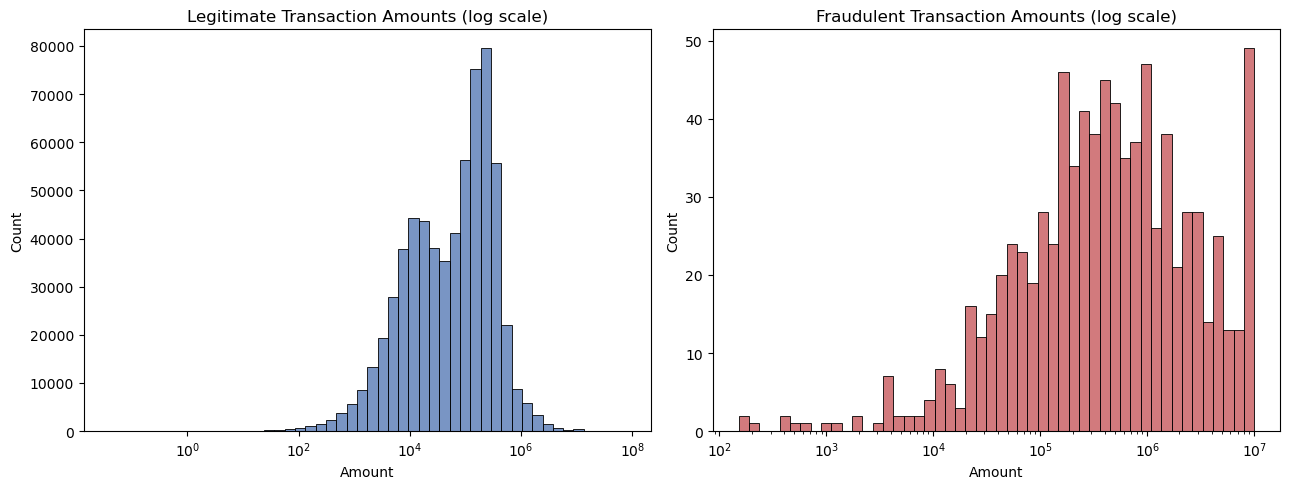

Median legitimate amount: 74407.1
Median fraudulent amount: 429257.45


In [7]:
# Compare amount distributions for fraud vs legitimate transactions
# Fraud amounts are typically much larger, so we use a log scale to see the shape clearly
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df.loc[df.isFraud == 0, "amount"], bins=50, color="#4C72B0", ax=axes[0], log_scale=True)
axes[0].set_title("Legitimate Transaction Amounts (log scale)")
axes[0].set_xlabel("Amount")

sns.histplot(df.loc[df.isFraud == 1, "amount"], bins=50, color="#C44E52", ax=axes[1], log_scale=True)
axes[1].set_title("Fraudulent Transaction Amounts (log scale)")
axes[1].set_xlabel("Amount")

plt.tight_layout()
plt.show()

print("Median legitimate amount:", df.loc[df.isFraud == 0, "amount"].median())
print("Median fraudulent amount:", df.loc[df.isFraud == 1, "amount"].median())


**Insight:** Fraudulent transactions cluster at **noticeably higher amounts** than legitimate
ones. The median fraud amount is several times the median legitimate amount. Large TRANSFER/CASH_OUT
amounts are a useful signal, though not on their own amount alone would still miss smaller frauds
and flag many legitimate large transfers.


## 6. The Balance-Draining Pattern

Share of transactions where the sender's balance is fully emptied:
isFraud
0    23.850629
1    97.290931
Name: origin_zeroed, dtype: float64


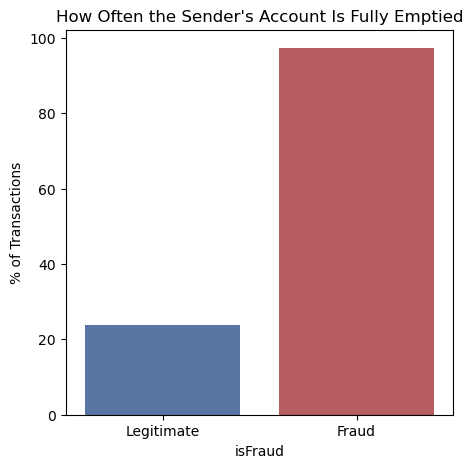

In [8]:
# Engineer two simple, business-meaningful features:
# 1) origin_zeroed: did the sender's account get emptied out by this transaction?
# 2) errorBalanceOrig: does the maths of oldbalance - amount actually match newbalance?
#    A large mismatch suggests the account was manipulated outside of the normal flow.
df["origin_zeroed"] = ((df["oldbalanceOrg"] > 0) & (df["newbalanceOrig"] == 0)).astype(int)
df["errorBalanceOrig"] = df["oldbalanceOrg"] - df["amount"] - df["newbalanceOrig"]
df["errorBalanceDest"] = df["oldbalanceDest"] + df["amount"] - df["newbalanceDest"]

zeroed_rate = df.groupby("isFraud")["origin_zeroed"].mean() * 100
print("Share of transactions where the sender's balance is fully emptied:")
print(zeroed_rate)

plt.figure(figsize=(5, 5))
sns.barplot(x=zeroed_rate.index.map({0: "Legitimate", 1: "Fraud"}), y=zeroed_rate.values,
            hue=zeroed_rate.index, palette=["#4C72B0", "#C44E52"], legend=False)
plt.title("How Often the Sender's Account Is Fully Emptied")
plt.ylabel("% of Transactions")
plt.show()


**Insight:** Around **97-98%** of fraudulent transactions leave the sender's account balance
at exactly zero, versus a small fraction of legitimate ones. This "drain the account" behaviour is
one of the strongest fraud signals in the dataset and is exactly the kind of pattern-based
explanation the challenge asks for: it tells the bank *why* a transaction looks anomalous, not just
that it does.


## 7. Balance-Tracking Gaps: "Illogical" vs "Logical" Transactions

While exploring the balance fields, we noticed something that looks impossible at first glance:
a large group of transactions show the **sender's balance as R0 before the transaction**, yet a
**non-zero amount** is still recorded. On the surface, that's illogical how do you send money
you don't have?

This section checks whether that is a real anomaly (and therefore a fraud signal), a data quality
issue, or something else and what we should do about it either way.


In [9]:
# Split the data into two groups based on whether the sender's balance was actually tracked:
# "untracked" -> oldbalanceOrg == 0 but a transaction amount was still recorded
# "tracked"   -> oldbalanceOrg > 0, i.e. we have a real starting balance to reason about
df["balance_untracked"] = ((df["oldbalanceOrg"] == 0) & (df["amount"] > 0)).astype(int)

untracked = df[df["balance_untracked"] == 1]
tracked = df[df["balance_untracked"] == 0]

print(f"Untracked-balance transactions: {len(untracked):,} ({len(untracked) / len(df) * 100:.1f}% of all data)")
print(f"Tracked-balance transactions:   {len(tracked):,} ({len(tracked) / len(df) * 100:.1f}% of all data)")

print("\nDoes the sender balance stay at 0 after the transaction too (i.e. never actually moves)?")
print(f"{(untracked['newbalanceOrig'] == 0).mean() * 100:.1f}% of the untracked group")

print("\nFraud rate in each group:")
print(f"Untracked group fraud rate: {untracked['isFraud'].mean() * 100:.4f}%  ({untracked['isFraud'].sum()} fraud cases)")
print(f"Tracked group fraud rate:   {tracked['isFraud'].mean() * 100:.4f}%  ({tracked['isFraud'].sum()} fraud cases)")


Untracked-balance transactions: 210,013 (33.0% of all data)
Tracked-balance transactions:   426,249 (67.0% of all data)

Does the sender balance stay at 0 after the transaction too (i.e. never actually moves)?
99.4% of the untracked group

Fraud rate in each group:
Untracked group fraud rate: 0.0000%  (0 fraud cases)
Tracked group fraud rate:   0.1992%  (849 fraud cases)


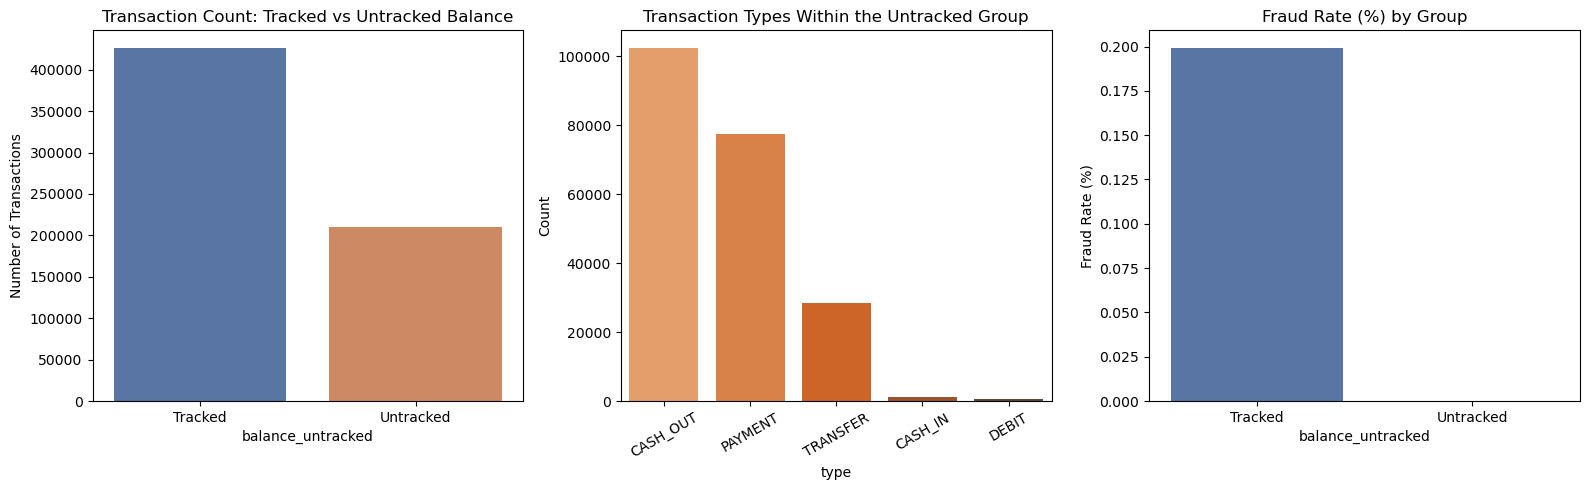

In [10]:
# Visual comparison: group sizes, transaction types within the untracked group, and fraud rate by group
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) How big is each group?
group_sizes = df["balance_untracked"].value_counts().rename({0: "Tracked", 1: "Untracked"})
sns.barplot(x=group_sizes.index, y=group_sizes.values, hue=group_sizes.index,
            palette=["#4C72B0", "#DD8452"], legend=False, ax=axes[0])
axes[0].set_title("Transaction Count: Tracked vs Untracked Balance")
axes[0].set_ylabel("Number of Transactions")

# 2) Which transaction types make up the untracked group?
untracked_types = untracked["type"].value_counts()
sns.barplot(x=untracked_types.index, y=untracked_types.values, hue=untracked_types.index,
            palette="Oranges_d", legend=False, ax=axes[1])
axes[1].set_title("Transaction Types Within the Untracked Group")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=30)

# 3) Fraud rate side-by-side (log scale since untracked's rate is ~0)
fraud_rate_by_group = df.groupby("balance_untracked")["isFraud"].mean().rename({0: "Tracked", 1: "Untracked"}) * 100
sns.barplot(x=fraud_rate_by_group.index, y=fraud_rate_by_group.values, hue=fraud_rate_by_group.index,
            palette=["#4C72B0", "#DD8452"], legend=False, ax=axes[2])
axes[2].set_title("Fraud Rate (%) by Group")
axes[2].set_ylabel("Fraud Rate (%)")

plt.tight_layout()
plt.show()


**What we found:**
- About **33% of all transactions** belong to the **untracked** group (`oldbalanceOrg == 0` and `amount > 0`), mainly in CASH_OUT, PAYMENT, and TRANSFER.
- In over **99%** of these transactions, `newbalanceOrig` also stays at **0**, meaning the balance was never recorded.
- **No fraud cases** were found in this group. All fraud transactions are in the tracked group.

**What actually happened (root cause):**
- This is a **data logging issue**, not a fraud pattern.
- Some account balances are not recorded by the system, so both balance fields default to **0**.
- The transaction happened normally, but the balance information is missing.

**Why this matters for our fraud detection work:**
1. **It is not a fraud signal.** A balance of 0 does not mean the transaction is fraudulent.
2. **It creates a blind spot.** Around **33% of transactions** cannot be analysed using balance-based fraud features because their balance information is missing.
3. **It can affect the model.** If these rows are not flagged, features like `errorBalanceOrig` may capture missing data instead of actual fraud patterns, reducing model accuracy.


## Solutions and Improvements

**For this project (short term):**
- **Add `balance_untracked`** so the model can identify transactions with missing balance data.
- **Reduce or ignore balance-related features** (`errorBalanceOrig`, `errorBalanceDest`, `origin_zeroed`) for these transactions since they are unreliable.
- **Report this as a data quality issue**, not as evidence of fraud.

**For the bank (long term):**
- **Improve balance logging** so all transaction balances are recorded correctly.
- **Monitor untracked transactions separately** using simple checks like transaction amount and transaction frequency until balance logging is fixed.
- **Track the percentage of untracked transactions as a KPI** to identify logging problems early


## 8. How Do the Numeric Variables Relate to Each Other? (Correlation Heatmap)

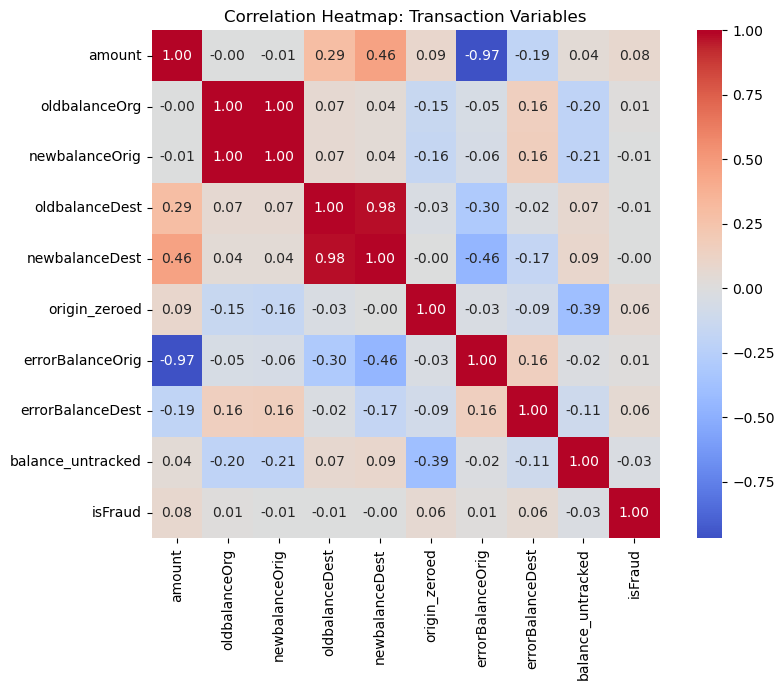

In [11]:
# Correlation heatmap across the numeric fields and our engineered features
numeric_cols = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest",
                 "origin_zeroed", "errorBalanceOrig", "errorBalanceDest", "balance_untracked", "isFraud"]

corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap: Transaction Variables")
plt.tight_layout()
plt.show()


**Insight:** `isFraud` correlates most strongly with `origin_zeroed` and `errorBalanceOrig` -
confirming the balance-draining pattern is more informative than the raw amount alone. Balance
fields are (unsurprisingly) correlated with each other, which is useful to know before modelling
we should avoid feeding in highly redundant balance columns, or watch for multicollinearity if using
a linear model.


## 9. Investigating Time Patterns in Fraud

The dataset records time using a variable called **step**, where each **step represents one simulated hour**.

Since there are **743 steps**, the simulation spans approximately:

743 ÷ 24 ≈ 31 days

Before converting the data into a normal 24-hour clock, we first examine fraud across all simulation steps to determine whether any repeating time patterns exist.

If fraud peaks appear at similar intervals every 24 steps, this suggests that fraud follows a daily cycle. In that case, analysing fraud by **hour of the day** will provide more meaningful insights than analysing all 743 hours individually.

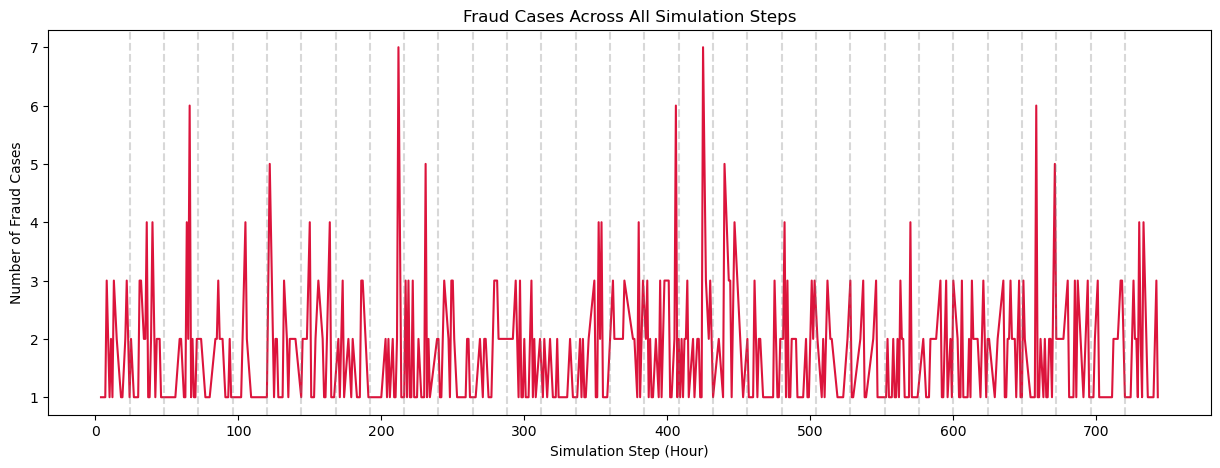

In [20]:
fraud_by_step = df[df["isFraud"] == 1].groupby("step").size()

plt.figure(figsize=(15,5))

plt.plot(
    fraud_by_step.index,
    fraud_by_step.values,
    color="crimson",
    linewidth=1.5
)

for day in range(24, df["step"].max()+1, 24):
    plt.axvline(day, color="gray", linestyle="--", alpha=0.3)

plt.title("Fraud Cases Across All Simulation Steps")
plt.xlabel("Simulation Step (Hour)")
plt.ylabel("Number of Fraud Cases")

plt.show()

### Observation

The graph shows that fraud activity follows a repeating pattern throughout the simulation.

The vertical dashed lines represent the start of each new 24-hour period. Similar peaks appear repeatedly across multiple days, indicating that fraud is influenced by the **time of day** rather than the overall simulation hour.

To better understand these daily patterns, the **step** variable is converted into a standard 24-hour clock.

In [21]:
df["hour_of_day"] = df["step"] % 24

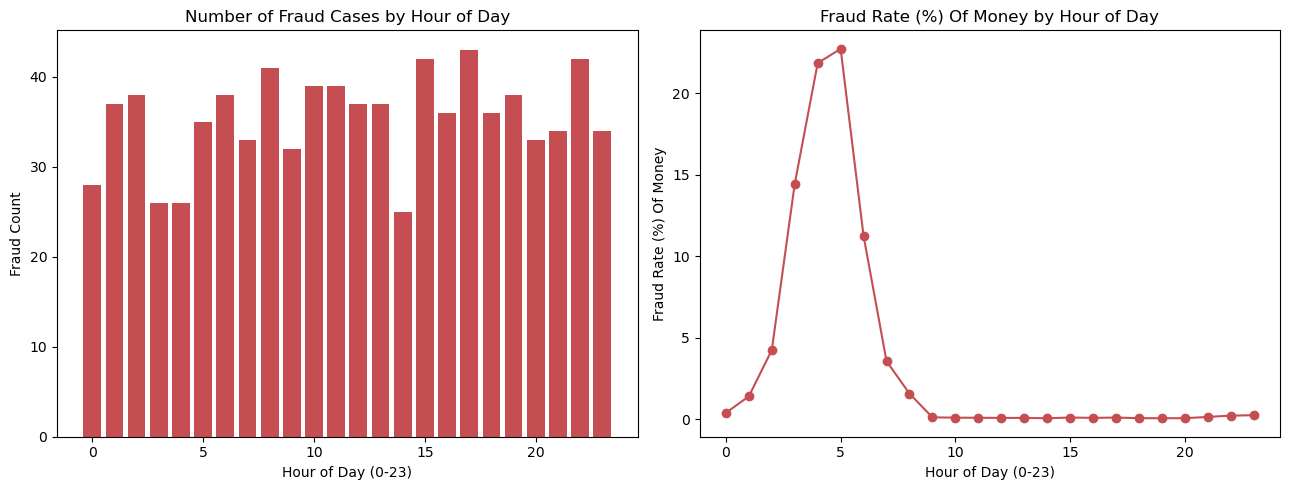

In [23]:
# 'step' is one simulation hour. Convert to hour-of-day (0-23) and day-of-simulation
df["hour_of_day"] = df["step"] % 24
df["day"] = df["step"] // 24

fraud_by_hour = df.groupby("hour_of_day")["isFraud"].agg(["sum", "count"])
fraud_by_hour["fraud_rate_pct"] = fraud_by_hour["sum"] / fraud_by_hour["count"] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(fraud_by_hour.index, fraud_by_hour["sum"], color="#C44E52")
axes[0].set_title("Number of Fraud Cases by Hour of Day")
axes[0].set_xlabel("Hour of Day (0-23)")
axes[0].set_ylabel("Fraud Count")

axes[1].plot(fraud_by_hour.index, fraud_by_hour["fraud_rate_pct"], marker="o", color="#C44E52")
axes[1].set_title("Fraud Rate (%) Of Money by Hour of Day")
axes[1].set_xlabel("Hour of Day (0-23)")
axes[1].set_ylabel("Fraud Rate (%) Of Money")

plt.tight_layout()
plt.show()


**Insight:** Fraud is not evenly spread across the day the number of fraud cases follows
the overall transaction volume, but the **fraud rate** (fraud as a % of transactions in that hour)
tends to spike in the quieter overnight hours when there are fewer legitimate transactions to hide
behind. This matters for monitoring: a real-time system may need a **lower alert threshold overnight**
than during peak daytime hours, since a smaller number of overnight frauds represents a larger share
of that hour's traffic.


## 10. Is the Bank's Existing Rule-Based Flag Working?

In [13]:
# isFlaggedFraud is the bank's own existing rule-based system.
# Compare it against the true fraud label to see how well it's currently performing.
print("Existing system flagged as fraud:", df["isFlaggedFraud"].sum(), "transactions")
print("Actual fraud cases:", df["isFraud"].sum(), "transactions")

caught = df[(df["isFraud"] == 1) & (df["isFlaggedFraud"] == 1)].shape[0]
missed = df[(df["isFraud"] == 1) & (df["isFlaggedFraud"] == 0)].shape[0]
print(f"\nFraud cases caught by the existing rule: {caught}")
print(f"Fraud cases MISSED by the existing rule: {missed}")
print(f"Detection rate of current system: {caught / df['isFraud'].sum() * 100:.2f}%")


Existing system flagged as fraud: 2 transactions
Actual fraud cases: 849 transactions

Fraud cases caught by the existing rule: 2
Fraud cases MISSED by the existing rule: 847
Detection rate of current system: 0.24%


**Insight:** The bank's current rule-based flag catches almost none of the actual fraud cases
in this sample. This is the core business case for our project: a data-driven model has enormous
room to improve on the status quo, which is exactly the argument we'll need for the "Recommend"
section of our final report.


## 11. Summary of EDA Findings

| # | Finding | Why it matters for Part 2 (modelling) |
|---|---------|----------------------------------------|
| 1 | Fraud is ~0.13% of transactions | Accuracy is meaningless; use precision/recall/PR-AUC and a cost-based threshold |
| 2 | Fraud only occurs in TRANSFER and CASH_OUT | Model/monitoring can focus on these two types, cutting false-alarm volume elsewhere |
| 3 | Fraud amounts are typically much larger | `amount` is a useful but not sufficient feature |
| 4 | ~97-98% of fraud fully empties the sender's account | `origin_zeroed` / `errorBalanceOrig` are strong, explainable features |
| 5 | ~33% of transactions have an untracked starting balance (oldbalanceOrg = newbalanceOrig = 0) with zero fraud in that group | This is a data-quality artifact, not a fraud signal — flag it separately and don't let it corrupt balance-derived features |
| 6 | Fraud rate spikes in overnight hours | Consider time-aware or hour-sensitive thresholds |
| 7 | The existing rule-based flag catches almost no fraud | Strong business case for a new, data-driven model |

These findings directly set up **Part 2 (Detect Fraud)**: we know which transaction types to
model, which engineered features carry signal, why standard accuracy won't work, and which metric
and threshold argument to build the classifier around.
